# Stored HDF5 radial reference: visualization

Open this notebook to inspect existing results without running an integration. Its execution companion is [h5_three_radial_reference.ipynb](h5_three_radial_reference.ipynb), in this same folder.

`VERSION` selects a saved execution explicitly for reproducibility. The default below is the latest complete version available when this viewer was created. Loading verifies the trajectory checksum. Missing or invalid artifacts raise an error; this notebook never falls back to integration. All geometry, solver settings and plots come from the saved artifact, without loading the HDF5 field.


In [ ]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from diagnostics.paths import find_project_root
from diagnostics import load_reference_trajectory, reference_trajectory_output_directory
from visualization import plot_reference_trajectory_points
from visualization.radial_reference import plot_radial_reference_audit

ROOT = find_project_root(Path.cwd())
# Keep the original notebook key so existing and future artifact versions
# share the established outputs/developements/accuracy directory.
NOTEBOOK = "notebooks/developements/accuracy/h5_three_radial_reference.ipynb"
REFERENCE_NAME = "h5_three_radial"
VERSION = "v2"  # Select an existing saved execution, e.g. "v1".
ARTIFACT_DIRECTORY = reference_trajectory_output_directory(
    NOTEBOOK, reference_name=REFERENCE_NAME, version=VERSION, project_root=ROOT)
reference = load_reference_trajectory(ARTIFACT_DIRECTORY)
print("Loaded and checksum-verified:", reference.paths.directory)
print("Saved configuration:", reference.metadata["config"])
print("DOP853:", reference.metadata["reference_solve"])
print("Radau:", reference.metadata["audit_solve"])
print("Recorded resolution audit:", reference.metadata["audit"])
print("Field fingerprint:", reference.metadata["dynamics_fingerprint_sha256"])


In [ ]:
positions = reference.initial_state.reshape(2, -1)
center = np.asarray(reference.metadata["initial_conditions"]["center"])
radii = np.linalg.norm(positions - center[:, None], axis=0)
display(Markdown("| Particle | x(0) | y(0) | radial distance |\n|---|---:|---:|---:|\n" +
    "\n".join(f"| {i+1} | {positions[0,i]:.12g} | {positions[1,i]:.12g} | {radii[i]:.12g} |"
              for i in range(positions.shape[1]))))


In [ ]:
fig, axes = plot_radial_reference_audit(reference)
plt.show()
fig, ax = plot_reference_trajectory_points(reference)
ax.set_title("HDF5 guiding-center reference (unwrapped coordinates)")
plt.show()
display(Markdown("| Particle | Maximum periodic discrepancy | Final periodic discrepancy |\n|---|---:|---:|\n" +
    "\n".join(f"| {i+1} | {distances.max():.6e} | {distances[-1]:.6e} |"
              for i, distances in enumerate(reference.audit_distances))))


## Interpretation

DOP853 and the tighter Radau audit solve the same interpolated guiding-center ODE in float64 arithmetic. Requested local tolerances do not guarantee global trajectory accuracy. The displayed discrepancy is an empirical audit, not an error bound; a large discrepancy means the reference is not validated at that scale and time. The time-dependent Hamiltonian need not be conserved.

Coordinates and time retain the source simulation normalization. The exact horizon, sampling, gyro-radius, potential parameters and solver tolerances are recorded in the artifact metadata printed above. Existing NPZ, JSON, README and image files remain unchanged when this viewer runs.


## DOP853–Radau separation through normalized time 50

Per-particle minimum-image distance between the two numerical trajectories. The vertical scale uses only this interval. No integration is performed.

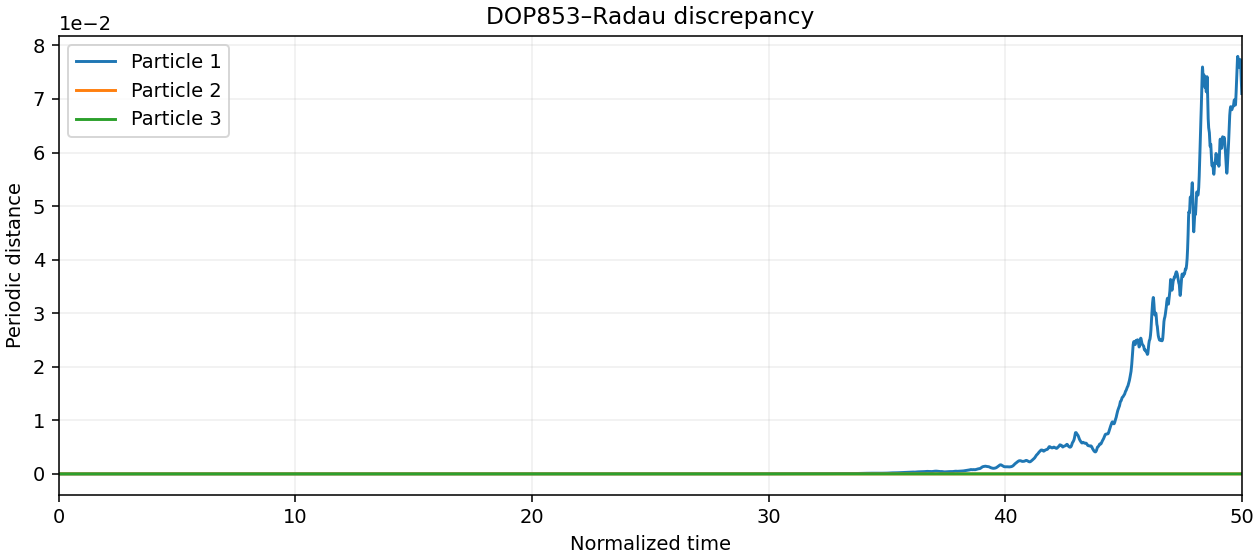

In [1]:
from visualization.radial_reference import plot_reference_discrepancy_until
import matplotlib.pyplot as plt

DISCREPANCY_END_TIME = 50.0  # Normalized time, matching the saved time axis.
fig, ax = plot_reference_discrepancy_until(reference, end_time=DISCREPANCY_END_TIME)
plt.show()